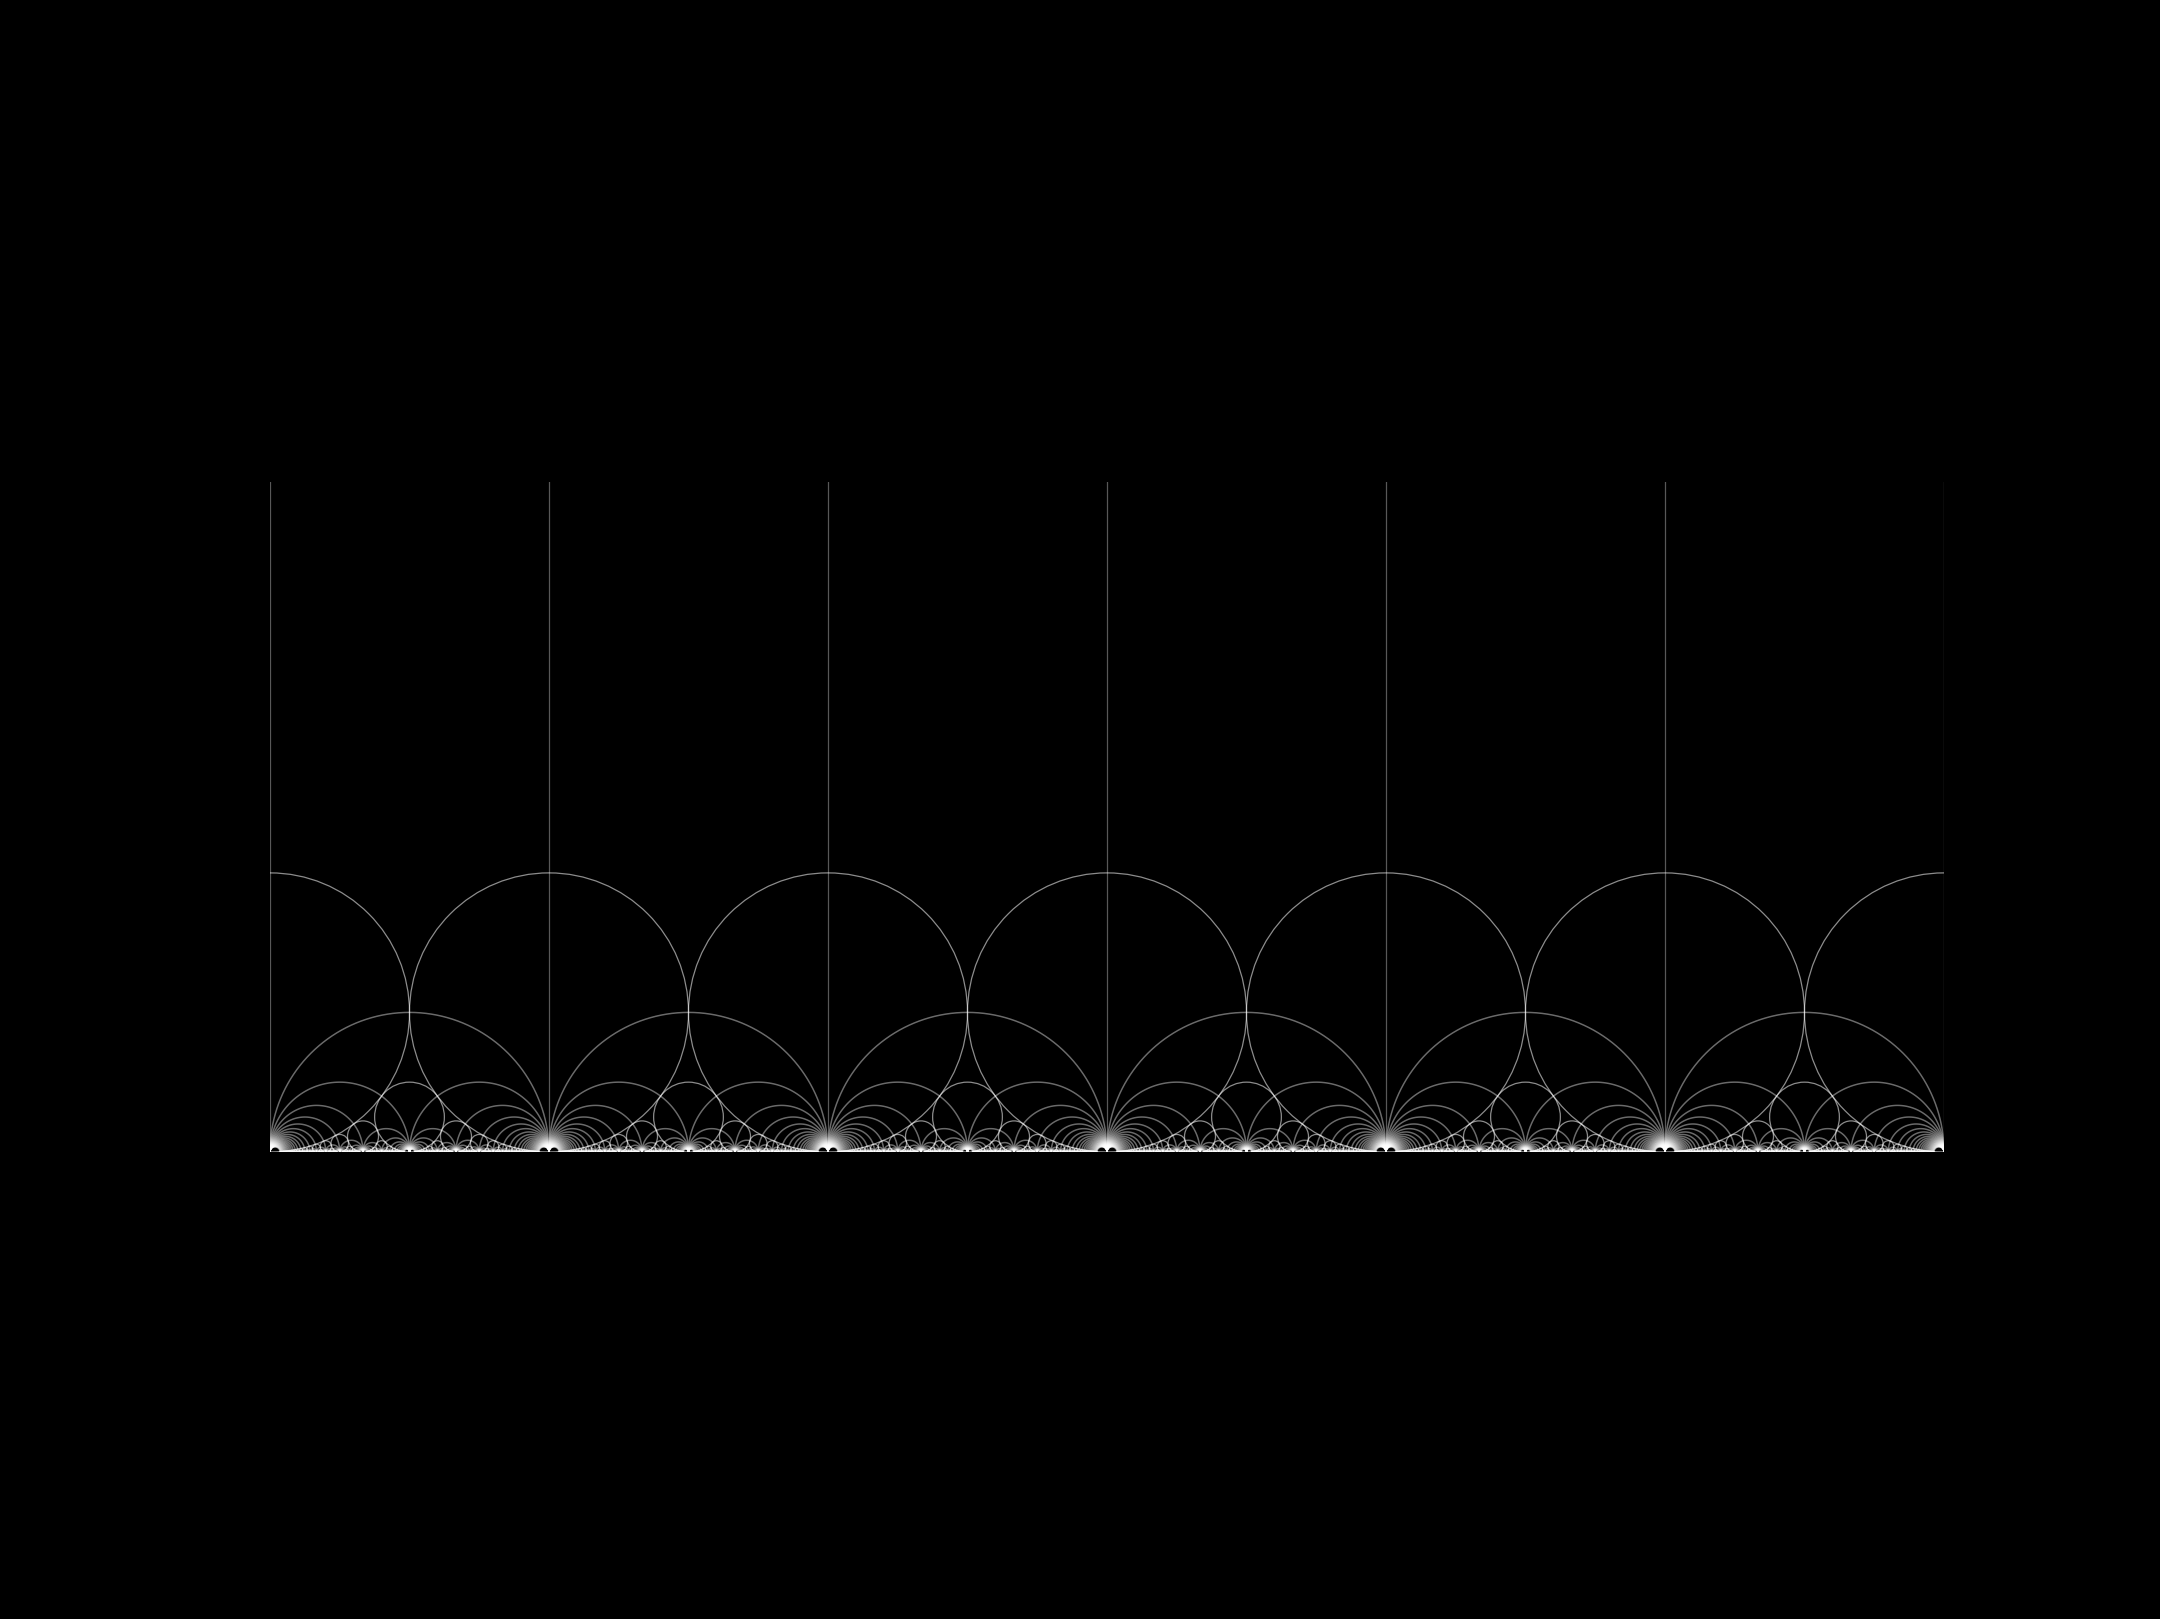

In [2]:
# SageMath code

from sage.all import *
from IPython.display import Image, display
import tempfile, os

def modular_arc_plot(N=18, xmax=3, ymax=2.4, figsize=10):
    """
    Draw a modular/Farey/Ford-circle style diagram in the upper half plane.

    N      : controls the denominator bound of rational endpoints
    xmax   : horizontal plotting range [-xmax, xmax]
    ymax   : vertical plotting range [0, ymax]
    """

    G = Graphics()

    line_col = "white"
    alpha = 0.42

    fracs = []
    for q in range(1, N + 1):
        for p in range(-xmax*q - 2*q, xmax*q + 2*q + 1):
            if gcd(p, q) == 1:
                xv = QQ(p) / QQ(q)
                if -xmax - 1 <= xv <= xmax + 1:
                    fracs.append((p, q, RDF(xv)))

    for i in range(len(fracs)):
        p, q, x1 = fracs[i]
        for j in range(i + 1, len(fracs)):
            r, s, x2 = fracs[j]

            if abs(p*s - r*q) == 1:
                if x1 == x2:
                    continue

                a = min(x1, x2)
                b = max(x1, x2)

                center = (a + b) / 2
                radius = (b - a) / 2

                if center + radius < -xmax or center - radius > xmax:
                    continue
                if radius > ymax * 2.2:
                    continue

                pts = []
                steps = 80
                for k in range(steps + 1):
                    t = RDF(pi) * k / steps
                    xc = center + radius * cos(t)
                    yc = radius * sin(t)
                    if -xmax <= xc <= xmax and 0 <= yc <= ymax:
                        pts.append((xc, yc))

                if len(pts) > 1:
                    G += line(pts, color=line_col, alpha=alpha, thickness=0.6)

    for q in range(1, N + 1):
        for p in range(-xmax*q - q, xmax*q + q + 1):
            if gcd(p, q) == 1:
                x0 = RDF(p) / RDF(q)
                r = RDF(1) / (2 * q**2)
                y0 = r

                if -xmax <= x0 <= xmax and y0 + r <= ymax:
                    G += circle(
                        (x0, y0),
                        r,
                        color=line_col,
                        alpha=0.55,
                        thickness=0.5
                    )

    for k in range(-xmax, xmax + 1):
        G += line([(k, 0), (k, ymax)], color=line_col, alpha=0.35, thickness=0.5)

    G += line([(-xmax, 0), (xmax, 0)], color=line_col, alpha=0.35, thickness=0.5)

    fig = G.matplotlib(
        figsize=figsize,
        axes=False,
        aspect_ratio=1,
        xmin=-xmax,
        xmax=xmax,
        ymin=0,
        ymax=ymax,
        frame=False,
        axes_pad=0
    )
    fig.patch.set_facecolor("black")
    for ax in fig.axes:
        ax.set_facecolor("black")

    tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
    tmp.close()
    fig.savefig(tmp.name, dpi=180, transparent=False, facecolor=fig.get_facecolor())
    display(Image(filename=tmp.name))
    os.unlink(tmp.name)


modular_arc_plot(N=28, xmax=3, ymax=2.4, figsize=12)

# General

In [9]:
from sage.all import *
from IPython.display import Image, display
import tempfile, os

# 作用在边界点 QQ ∪ {∞} 上
def mobius_on_boundary(g, x):
    a, b, c, d = g.list()
    if x == oo:
        if c == 0:
            return oo
        return QQ(a) / QQ(c)
    den = c*x + d
    if den == 0:
        return oo
    return (a*x + b) / den


# 画上半平面中的双曲测地线：
# 若两个端点都有限，则画与实轴正交的半圆；
# 若一个端点是∞，则画竖直线。
def geodesic_plot(x1, x2, xmin=-3, xmax=3, ymax=2.5,
                  color='black', thickness=0.7, alpha=0.8, npts=120):
    G = Graphics()

    if x1 == oo and x2 == oo:
        return G
    if x1 == oo or x2 == oo:
        xv = x2 if x1 == oo else x1
        xv = RDF(xv)
        if xmin <= xv <= xmax:
            G += line([(xv, 0), (xv, ymax)], color=color,
                      thickness=thickness, alpha=alpha)
        return G

    a = RDF(min(x1, x2))
    b = RDF(max(x1, x2))
    center = (a + b) / 2.0
    radius = (b - a) / 2.0

    if radius == 0:
        return G

    if radius > 5*ymax:
        return G

    pts = []
    for k in range(npts + 1):
        t = pi * k / npts
        xv = center + radius*cos(t)
        yv = radius*sin(t)
        if xmin - 0.2 <= xv <= xmax + 0.2 and 0 <= yv <= ymax + 0.2:
            pts.append((xv, yv))

    if len(pts) >= 2:
        G += line(pts, color=color, thickness=thickness, alpha=alpha)

    return G


def subgroup_elements(H, B=5):
    mats = []
    seen = set()

    for a in range(-B, B+1):
        for b in range(-B, B+1):
            for c in range(-B, B+1):
                for d in range(-B, B+1):
                    if a*d - b*c != 1:
                        continue
                    M = matrix(ZZ, 2, [a, b, c, d])
                    if M not in H:
                        continue

                    key1 = tuple(M.list())
                    key2 = tuple((-M).list())
                    if key1 in seen or key2 in seen:
                        continue
                    seen.add(key1)
                    mats.append(M)
    return mats


def render_graphics(G, save_path=None, display_inline=True,
                    figsize=8, xmin=-3, xmax=3, ymin=0, ymax=2.5,
                    axes=False, frame=False, aspect_ratio=1,
                    axes_pad=0, dpi=180, background='white'):
    """
    Render a Sage Graphics object in a python3 notebook and optionally save it.
    """
    fig = G.matplotlib(
        figsize=figsize,
        axes=axes,
        aspect_ratio=aspect_ratio,
        xmin=xmin,
        xmax=xmax,
        ymin=ymin,
        ymax=ymax,
        frame=frame,
        axes_pad=axes_pad,
    )
    fig.patch.set_facecolor(background)
    for ax in fig.axes:
        ax.set_facecolor(background)

    target_path = save_path
    temp_path = None

    if target_path is None:
        tmp = tempfile.NamedTemporaryFile(suffix='.png', delete=False)
        tmp.close()
        target_path = tmp.name
        temp_path = target_path

    fig.savefig(target_path, dpi=dpi, transparent=False,
                facecolor=fig.get_facecolor())

    if display_inline:
        display(Image(filename=target_path))

    if temp_path is not None:
        os.unlink(temp_path)

    return target_path if save_path is not None else None


def farey_arcs_for_subgroup(H, B=5, xmin=-3, xmax=3, ymax=2.5,
                            color='black', thickness=0.7, alpha=0.7,
                            save_path=None, display_inline=False,
                            figsize=8, dpi=180, background='white'):
    G = Graphics()

    G += line([(xmin, 0), (xmax, 0)], color='gray', thickness=0.8)

    mats = subgroup_elements(H, B=B)
    base_edges = [(QQ(0), QQ(1)), (QQ(1), oo), (QQ(0), oo)]
    drawn = set()

    for M in mats:
        for u, v in base_edges:
            x1 = mobius_on_boundary(M, u)
            x2 = mobius_on_boundary(M, v)

            if x1 == oo and x2 != oo:
                key = ('v', x2)
            elif x2 == oo and x1 != oo:
                key = ('v', x1)
            elif x1 != oo and x2 != oo:
                a = min(x1, x2)
                b = max(x1, x2)
                key = ('c', a, b)
            else:
                continue

            if key in drawn:
                continue
            drawn.add(key)

            G += geodesic_plot(x1, x2, xmin=xmin, xmax=xmax, ymax=ymax,
                               color=color, thickness=thickness, alpha=alpha)

    if save_path is not None or display_inline:
        render_graphics(
            G,
            save_path=save_path,
            display_inline=display_inline,
            figsize=figsize,
            xmin=xmin,
            xmax=xmax,
            ymin=0,
            ymax=ymax,
            dpi=dpi,
            background=background,
        )

    return G

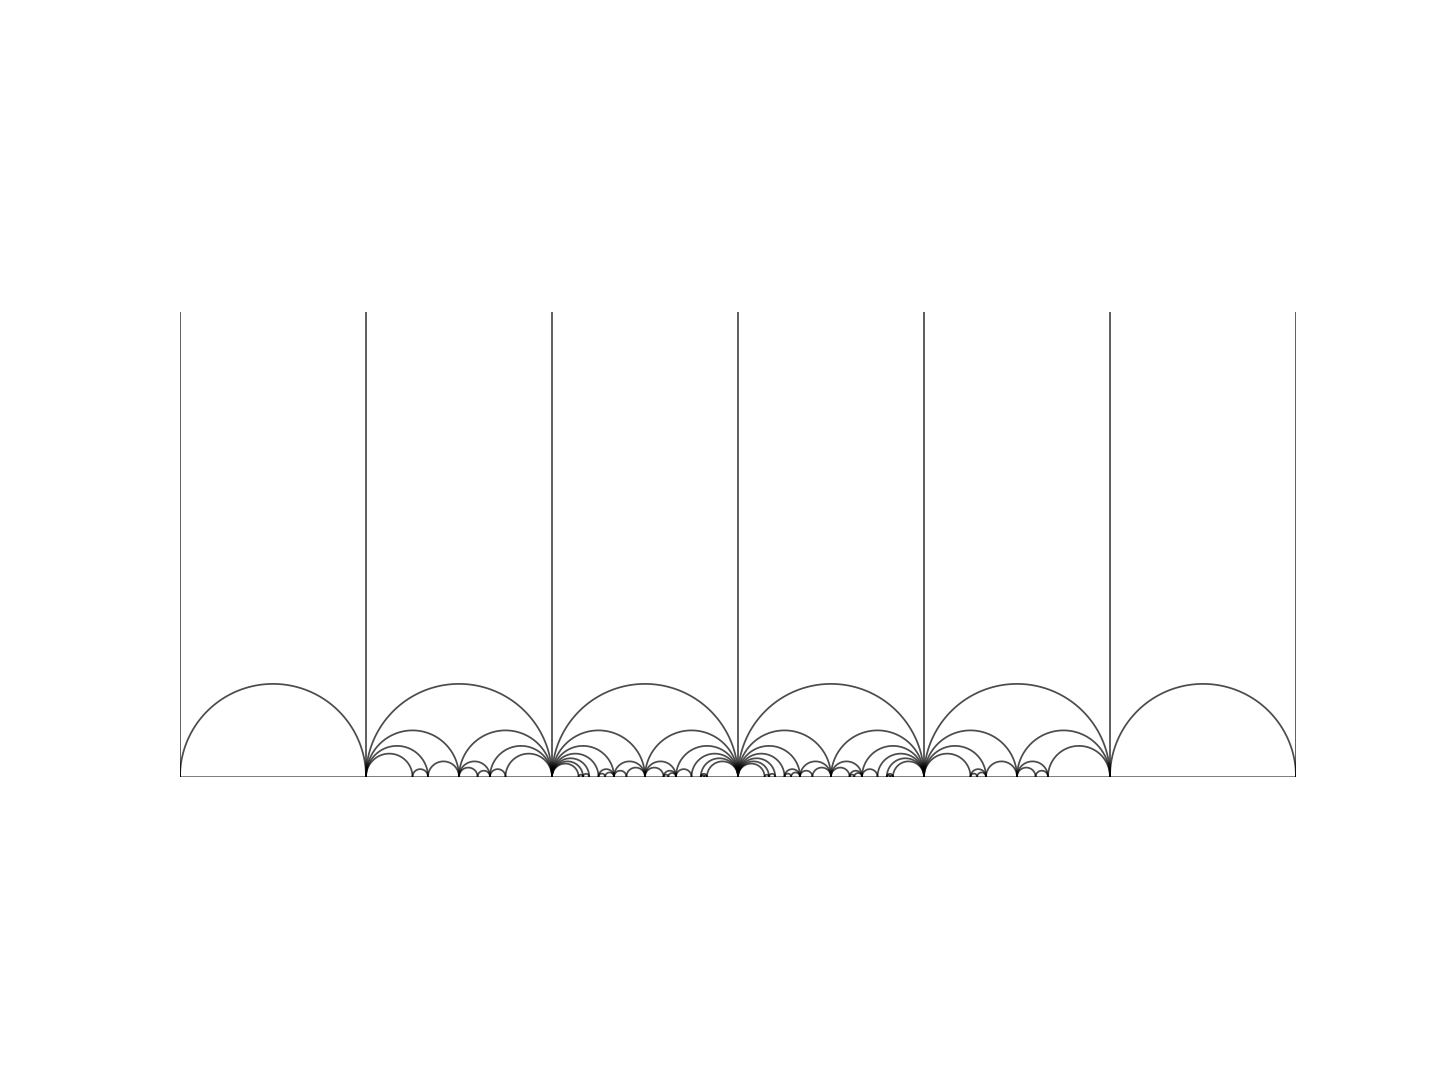

In [ ]:
H = Gamma0(3)
G = farey_arcs_for_subgroup( 
    H,
    B=6,
    save_path="/home/wlt2025/project/ai4math/output/farey.png",
    display_inline=True
)
